In [1]:
import numpy as np

In [3]:
x = np.array([1,2,4,5,6,7,8,9])
y = np.array([1,7,8,6,5,2,2,4])

In [7]:
x = x.reshape(-1,1)
y = y.reshape(-1,1)

In [13]:
X = np.column_stack((np.ones_like(x),x,x**2,x**3))
X

array([[  1,   1,   1,   1],
       [  1,   2,   4,   8],
       [  1,   4,  16,  64],
       [  1,   5,  25, 125],
       [  1,   6,  36, 216],
       [  1,   7,  49, 343],
       [  1,   8,  64, 512],
       [  1,   9,  81, 729]])

In [15]:
b = np.linalg.inv(X.T@X) @ X.T @y
b

array([[-8.53960964],
       [12.2117907 ],
       [-2.64302613],
       [ 0.16010855]])

In [17]:
y_hat = X@b

In [19]:
e = y - y_hat
e

array([[-1.89263473e-01],
       [ 4.07264377e-01],
       [-2.66082177e-01],
       [-4.57259159e-01],
       [ 8.34359670e-01],
       [-3.51876979e-01],
       [ 2.33796055e-02],
       [-5.21866194e-04]])

In [23]:
np.sum(e**2)

1.3020909438819812

In [25]:
e.T@e

array([[1.30209094]])

In [30]:
import numpy as np
import matplotlib.pyplot as plt

In [44]:
data = np.array([[1,1],
                 [2,7],
                 [4,8],
                 [5,6],
                 [6,5],
                 [7,2],
                 [8,2],
                 [9,4]])
x = data[:,[0]]
y = data[:,[1]]

In [46]:
x_array = np.linspace(0,10,101).reshape(-1,1)#左闭右闭[0,10]共取出101个点

In [48]:
degree = 3 #阶数

X_poly = [x**d for d in range(1,degree+1)]#方法从左向右执行,无需()
X_poly = np.hstack(X_poly) #polynomial(多项式的意思)

X_poly = np.hstack([np.ones_like(x),X_poly])#hstack要求数组形状一只,column_stack才会自动将1D数组当成列

In [50]:
X_poly

array([[  1,   1,   1,   1],
       [  1,   2,   4,   8],
       [  1,   4,  16,  64],
       [  1,   5,  25, 125],
       [  1,   6,  36, 216],
       [  1,   7,  49, 343],
       [  1,   8,  64, 512],
       [  1,   9,  81, 729]])

In [52]:
b = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ y
b

array([[-8.53960964],
       [12.2117907 ],
       [-2.64302613],
       [ 0.16010855]])

In [54]:
coef = b[1:,:]
intercept = b[0,:]

In [56]:
intercept

array([-8.53960964])

In [60]:
coef[0][0]#取出元素,相当于取出一次再取一次,等价于coef[0,0]后者更标准 coefficient(斜率)

12.211790696867965

In [62]:
y_poly_pred = X_poly @ b
y_poly_pred

array([[1.18926347],
       [6.59273562],
       [8.26608218],
       [6.45725916],
       [4.16564033],
       [2.35187698],
       [1.97662039],
       [4.00052187]])

In [66]:
X_array_poly = [x_array ** d for d in range(1,degree+1)]
X_array_poly = np.hstack(X_array_poly)
X_array_poly = np.hstack([np.ones_like(x_array),X_array_poly])

In [74]:
y_array_pred = X_array_poly @ b

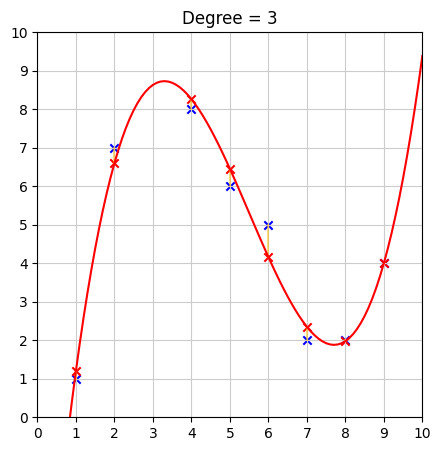

In [78]:
fig,ax = plt.subplots(figsize = (5,5))

ax.scatter(x,y,marker = 'x',color = 'b')
ax.scatter(x,y_poly_pred,marker = 'x',color = 'r')

data_ = np.column_stack([x,y_poly_pred])

ax.plot(([i for (i,j) in data_],[i for (i,j) in data]),
        ([j for (i,j) in data_],[j for (i,j) in data]),
        c = '#FFC000',alpha = 0.5)

ax.plot(x_array,y_array_pred,color = 'r')
#旧式格式化,不属于print语法,任何字符串都可以用
ax.set_title('Degree = %d' % degree)

ax.set_aspect('equal',adjustable = 'box')
ax.set_xticks(np.arange(11))
ax.set_yticks(np.arange(11))
ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.grid(True,c = '0.8')

In [80]:
#.format用于插入格式化数字 是字符串方法 :.3f中:表示开始格式说明.3表示三位小数f表示浮点数
#这里区别于上面使用%的旧式插入
#还有一种是f'{degree}'  无需后面添加,直接插入degree值
equation = '$y = {:.3f}'.format(intercept[0])
for j in range(0,len(coef[:,0])):
    equation += ' + {:.3f}x^{}'.format(coef[j][0],j+1)
equation += '$'
#.replace将第一个参数字符串替换为第二个参数字符串
equation = equation.replace('+ -','-')
print(equation)
print(str(b))

$y = -8.540 + 12.212x^1 -2.643x^2 + 0.160x^3$
[[-8.53960964]
 [12.2117907 ]
 [-2.64302613]
 [ 0.16010855]]


In [83]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [107]:
data = np.array([[1,1],
                 [2,7],
                 [4,8],
                 [5,6],
                 [6,5],
                 [7,2],
                 [8,2],
                 [9,4]])
x = data[:,[0]]
y = data[:,[1]]

array([[1],
       [2],
       [4],
       [5],
       [6],
       [7],
       [8],
       [9]])

In [87]:
x_array = np.linspace(0,10,101).reshape(-1,1)

In [109]:
degree_idx = 8
#指定类的初始化(定制规则)
poly = PolynomialFeatures(degree = degree_idx)
X_poly = poly.fit_transform(x)

In [111]:
poly_reg = LinearRegression()
poly_reg.fit(X_poly,y)
y_poly_pred = poly_reg.predict(X_poly)
data_ = np.column_stack([x,y_poly_pred])

y_array_pred = poly_reg.predict(poly.fit_transform(x_array))

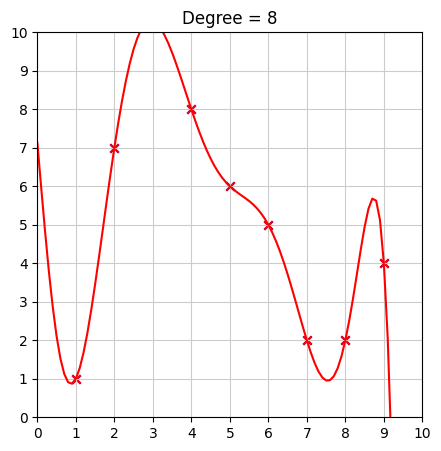

In [129]:
fig,ax = plt.subplots(figsize = (5,5))

ax.scatter(x,y,marker = 'x',color = 'b')
ax.scatter(x,y_poly_pred,marker = 'x',color = 'r')

ax.plot(([i for (i,j) in data_],[i for (i,j) in data]),
        ([j for (i,j) in data_],[j for (i,j) in data]),
        c = '#FFC000',alpha = 0.5)

ax.plot(x_array,y_array_pred,color = 'r')
ax.set_title(f'Degree = {degree_idx}')

ax.set_aspect('equal',adjustable = 'box')
ax.set_xticks(np.arange(11))
ax.set_yticks(np.arange(11))
ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.grid(True,c = '0.8')

In [135]:
#输出2D数组,第一个维度代表输出维度,第二个维度是每个特征系数
coef = poly_reg.coef_
intercept = poly_reg.intercept_

In [137]:
equiation = '$y = {:.3f}'.format(intercept[0])
for j in range(1,len(coef[0])):
    #因为coef是2D,所以提取两侧(哪怕只有一组特征) 这种索引是由外向内
    equiation += ' + {:.3f}x^{}'.format(coef[0][j],j)
equiation += '$'
equiation = equiation.replace('+ -','-')
print(equiation)

$y = 7.123 -11.430x^1 -2.828x^2 + 15.342x^3 -9.463x^4 + 2.599x^5 -0.370x^6 + 0.027x^7 -0.001x^8$
